In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

# Load dataset

In [2]:
import pandas as pd

df = pd.read_csv("heart_2022_with_nans.csv")
non_penyakit = [
    "State",
    "Sex",
    "LastCheckupTime",
    "PhysicalActivities",
    "SleepHours",
    "RemovedTeeth",
    "SmokerStatus",
    "ECigaretteUsage",
    "ChestScan",
    "RaceEthnicityCategory",
    "AgeCategory",
    "HeightInMeters",
    "WeightInKilograms",
    "BMI",
    "AlcoholDrinkers",
    "HIVTesting",
    "FluVaxLast12",
    "PneumoVaxEver",
    "TetanusLast10Tdap",
    "HighRiskLastYear",
    "PhysicalHealthDays",
    "MentalHealthDays",
    "DifficultyWalking",
    "GeneralHealth"
]

df = df[non_penyakit]
df.head()

,State,Sex,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,...,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,PhysicalHealthDays,MentalHealthDays,DifficultyWalking,GeneralHealth
0,Alabama,Female,Within past year (anytime less than 12 months ...,No,8.0,NaN,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",...,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,0.0,0.0,No,Very good
1,Alabama,Female,NaN,No,6.0,NaN,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",...,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Excellent
2,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",...,No,No,No,No,NaN,No,2.0,3.0,No,Very good
3,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",...,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Excellent
4,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",...,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,2.0,0.0,No,Fair


In [4]:
df

,State,Sex,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,...,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,PhysicalHealthDays,MentalHealthDays,DifficultyWalking,GeneralHealth
0,Alabama,Female,Within past year (anytime less than 12 months ...,No,8.0,NaN,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",...,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,0.0,0.0,No,Very good
1,Alabama,Female,NaN,No,6.0,NaN,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",...,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Excellent
2,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",...,No,No,No,No,NaN,No,2.0,3.0,No,Very good
3,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",...,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Excellent
4,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",...,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,2.0,0.0,No,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445127,Virgin Islands,Female,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,Never smoked,Never used e-cigarettes in my entire life,Yes,"Black only, Non-Hispanic",...,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,0.0,3.0,No,Good
445128,Virgin Islands,Female,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,Never smoked,Never used e-cigarettes in my entire life,No,"Black only, Non-Hispanic",...,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,2.0,2.0,No,Excellent
445129,Virgin Islands,Female,5 or more years ago,No,5.0,1 to 5,Current smoker - now smokes every day,Use them some days,NaN,NaN,...,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,30.0,30.0,No,Poor
445130,Virgin Islands,Male,Within past year (anytime less than 12 months ...,No,5.0,None of them,Never smoked,Never used e-cigarettes in my entire life,Yes,"Black only, Non-Hispanic",...,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Very good


# EDA

In [5]:
# info
print(df.dtypes.value_counts())

object     18
float64     6
Name: count, dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   State                  445132 non-null  object 
 1   Sex                    445132 non-null  object 
 2   LastCheckupTime        436824 non-null  object 
 3   PhysicalActivities     444039 non-null  object 
 4   SleepHours             439679 non-null  float64
 5   RemovedTeeth           433772 non-null  object 
 6   SmokerStatus           409670 non-null  object 
 7   ECigaretteUsage        409472 non-null  object 
 8   ChestScan              389086 non-null  object 
 9   RaceEthnicityCategory  431075 non-null  object 
 10  AgeCategory            436053 non-null  object 
 11  HeightInMeters         416480 non-null  float64
 12  WeightInKilograms      403054 non-null  float64
 13  BMI                    396326 non-null  float64
 14  AlcoholDrinkers        398558 non-nu

In [7]:
df.describe()

,SleepHours,HeightInMeters,WeightInKilograms,BMI,PhysicalHealthDays,MentalHealthDays
count,439679.000000,416480.000000,403054.000000,396326.000000,434205.000000,436065.000000
mean,7.022983,1.702691,83.074470,28.529842,4.347919,4.382649
std,1.502425,0.107177,21.448173,6.554889,8.688912,8.387475
min,1.000000,0.910000,22.680000,12.020000,0.000000,0.000000
25%,6.000000,1.630000,68.040000,24.130000,0.000000,0.000000
50%,7.000000,1.700000,80.740000,27.440000,0.000000,0.000000
75%,8.000000,1.780000,95.250000,31.750000,3.000000,5.000000
max,24.000000,2.410000,292.570000,99.640000,30.000000,30.000000


In [8]:
# statistik deskriptif
target_col = 'GeneralHealth'
feature_cols = [c for c in df.columns if c != target_col]
numeric_feature_cols = df[feature_cols].select_dtypes(include=np.number).columns
summary = df[numeric_feature_cols].agg(['mean','std','min','max']).T
summary['skewness'] = df[numeric_feature_cols].skew()
summary = summary.round(3)
print(summary.to_string())

                      mean     std    min     max  skewness
SleepHours           7.023   1.502   1.00   24.00     0.765
HeightInMeters       1.703   0.107   0.91    2.41     0.029
WeightInKilograms   83.074  21.448  22.68  292.57     1.076
BMI                 28.530   6.555  12.02   99.64     1.388
PhysicalHealthDays   4.348   8.689   0.00   30.00     2.180
MentalHealthDays     4.383   8.387   0.00   30.00     2.123


In [10]:
# cek missing value
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percent": missing_percent
})

missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Percent
TetanusLast10Tdap,82516,18.537423
PneumoVaxEver,77040,17.307226
HIVTesting,66127,14.855593
ChestScan,56046,12.590872
HighRiskLastYear,50623,11.372582
BMI,48806,10.964388
FluVaxLast12,47121,10.585849
AlcoholDrinkers,46574,10.462964
WeightInKilograms,42078,9.452926
ECigaretteUsage,35660,8.011107


In [11]:
sparsity = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Persentase sparsity data: {sparsity:.2f}%")

Persentase sparsity data: 6.66%


In [ ]:
# Cek Duplikat
df.duplicated().sum()

np.int64(356)

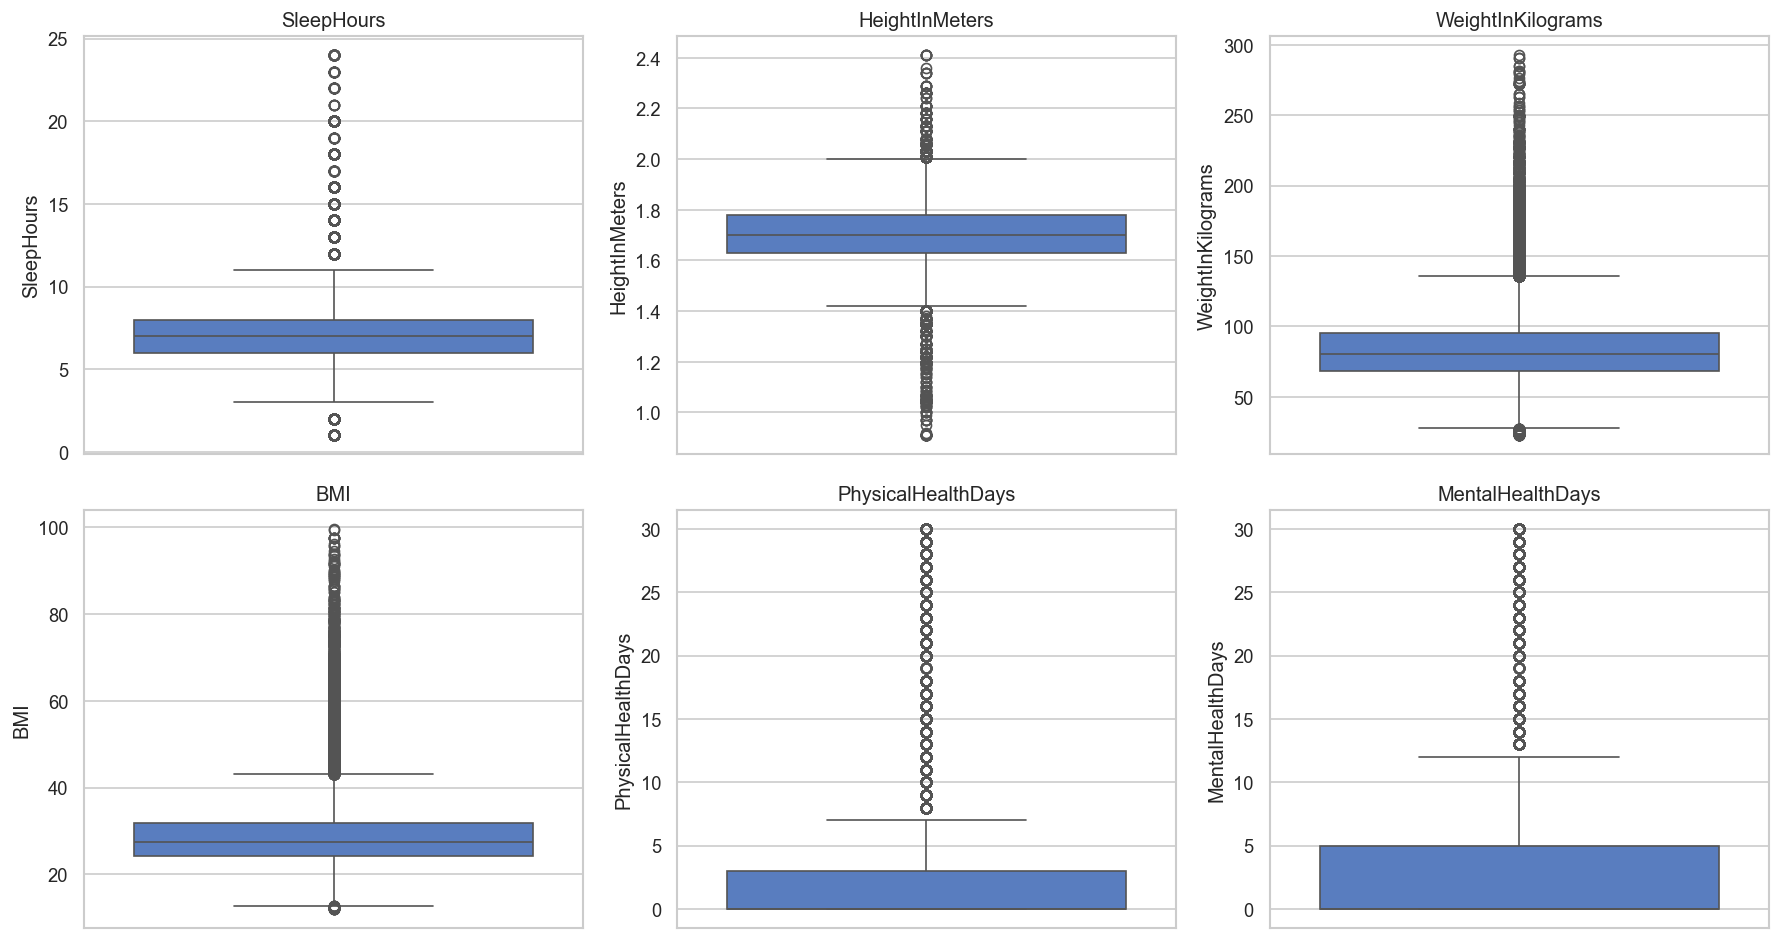

In [13]:
# Cek Outlier
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

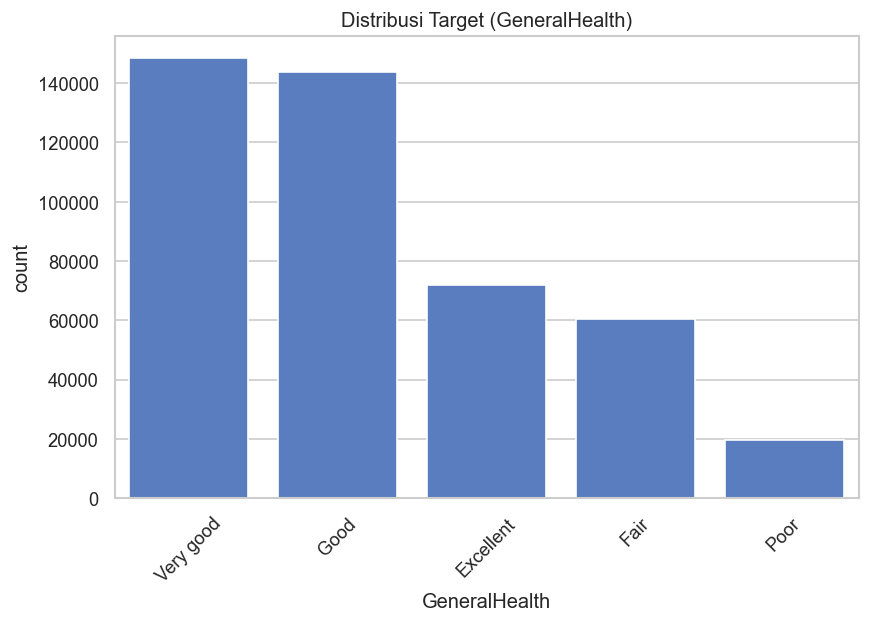

GeneralHealth
Very good    33.438304
Good         32.346700
Excellent    16.191146
Fair         13.577018
Poor          4.446832
Name: proportion, dtype: float64

In [14]:
# Cek Imbalance
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GeneralHealth', order=df['GeneralHealth'].value_counts().index)
plt.title("Distribusi Target (GeneralHealth)")
plt.xticks(rotation=45)
plt.show()


df['GeneralHealth'].value_counts(normalize=True) * 100

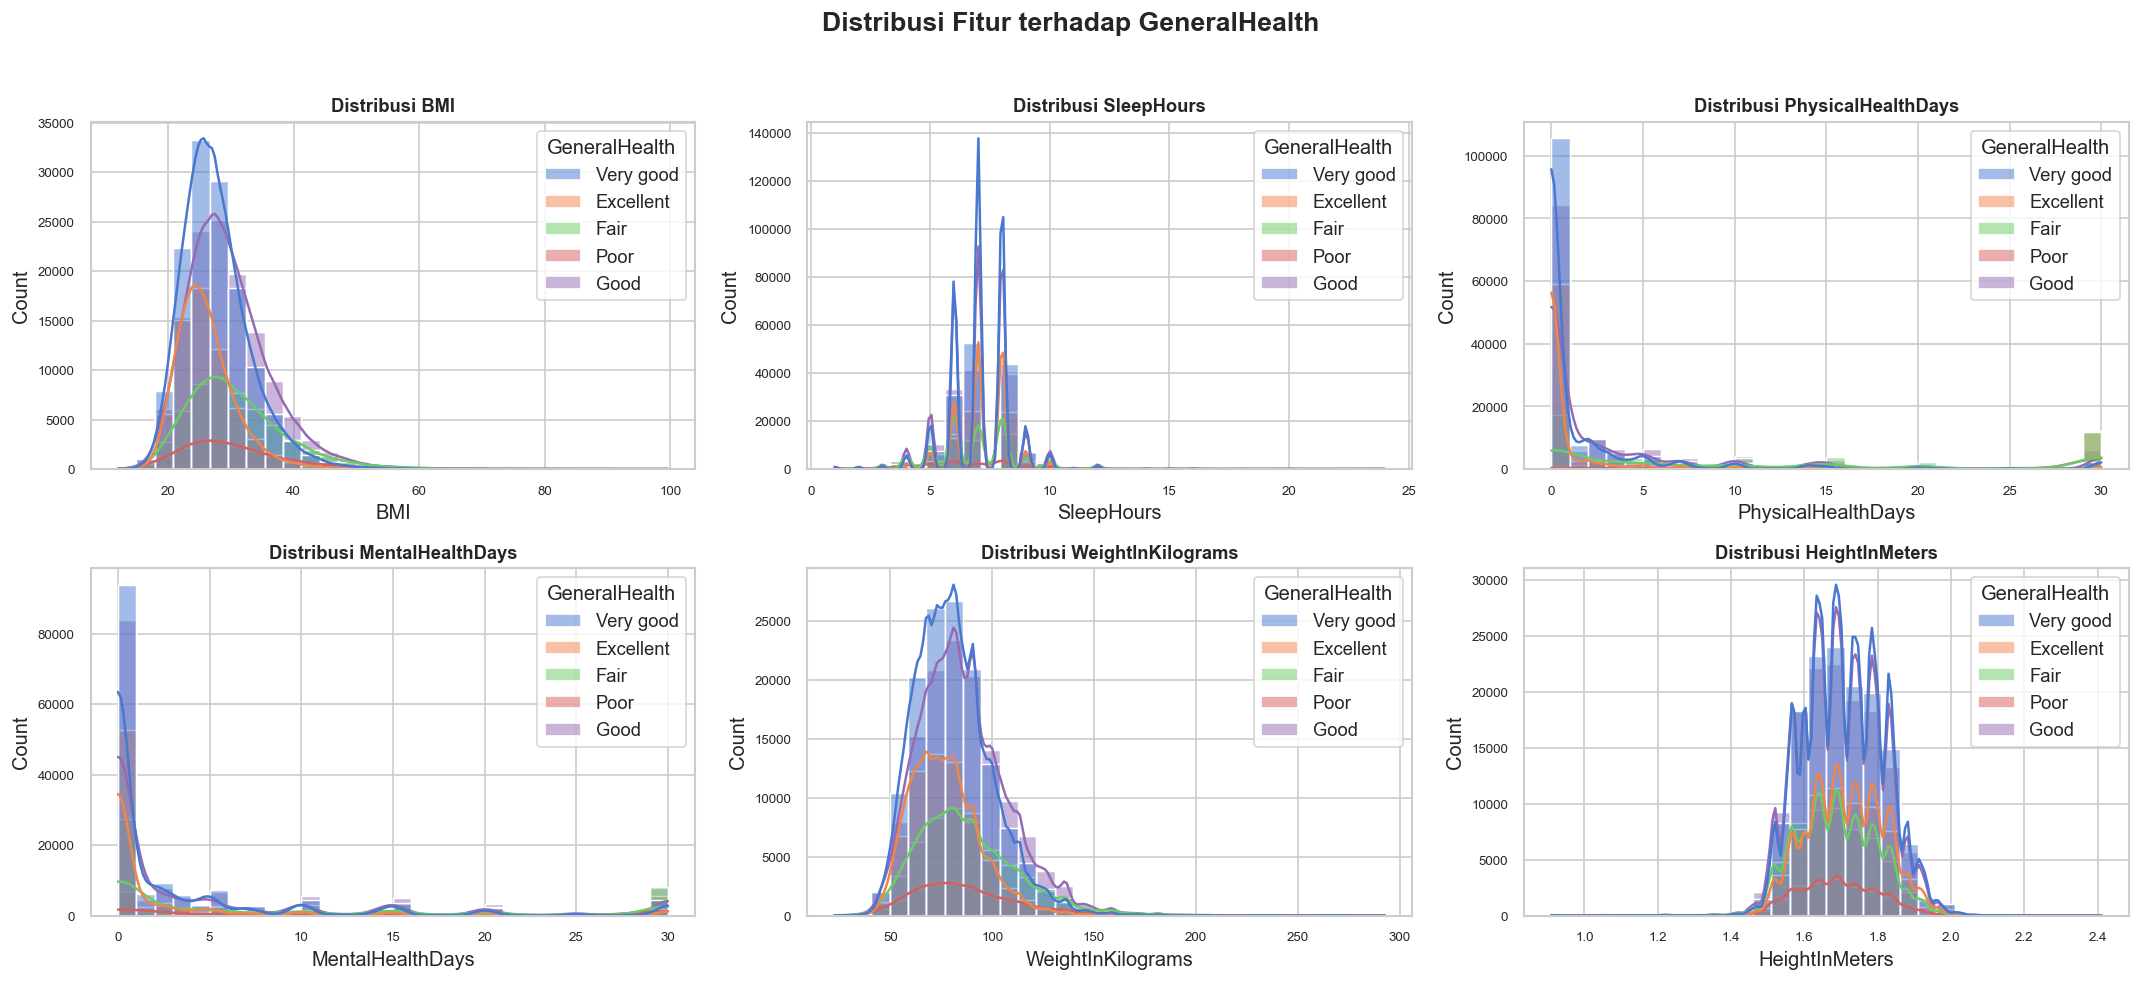

In [15]:
# Distribusi Fitur
import matplotlib.pyplot as plt
import seaborn as sns

# target
target_col = 'GeneralHealth'

# fitur numerik
feature_cols = [
    'BMI',
    'SleepHours',
    'PhysicalHealthDays',
    'MentalHealthDays',
    'WeightInKilograms',
    'HeightInMeters'
]

# jumlah kolom subplot
n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

# canvas
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(18, n_rows * 4))

axes = axes.flatten()

# looping visualisasi
for i, col in enumerate(feature_cols):

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        bins=30,
        kde=True,
        alpha=0.5,
        ax=axes[i]
    )

    axes[i].set_title(
        f'Distribusi {col}',
        fontsize=11,
        fontweight='bold'
    )

    axes[i].tick_params(labelsize=8)

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# judul utama
plt.suptitle(
    'Distribusi Fitur terhadap GeneralHealth',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

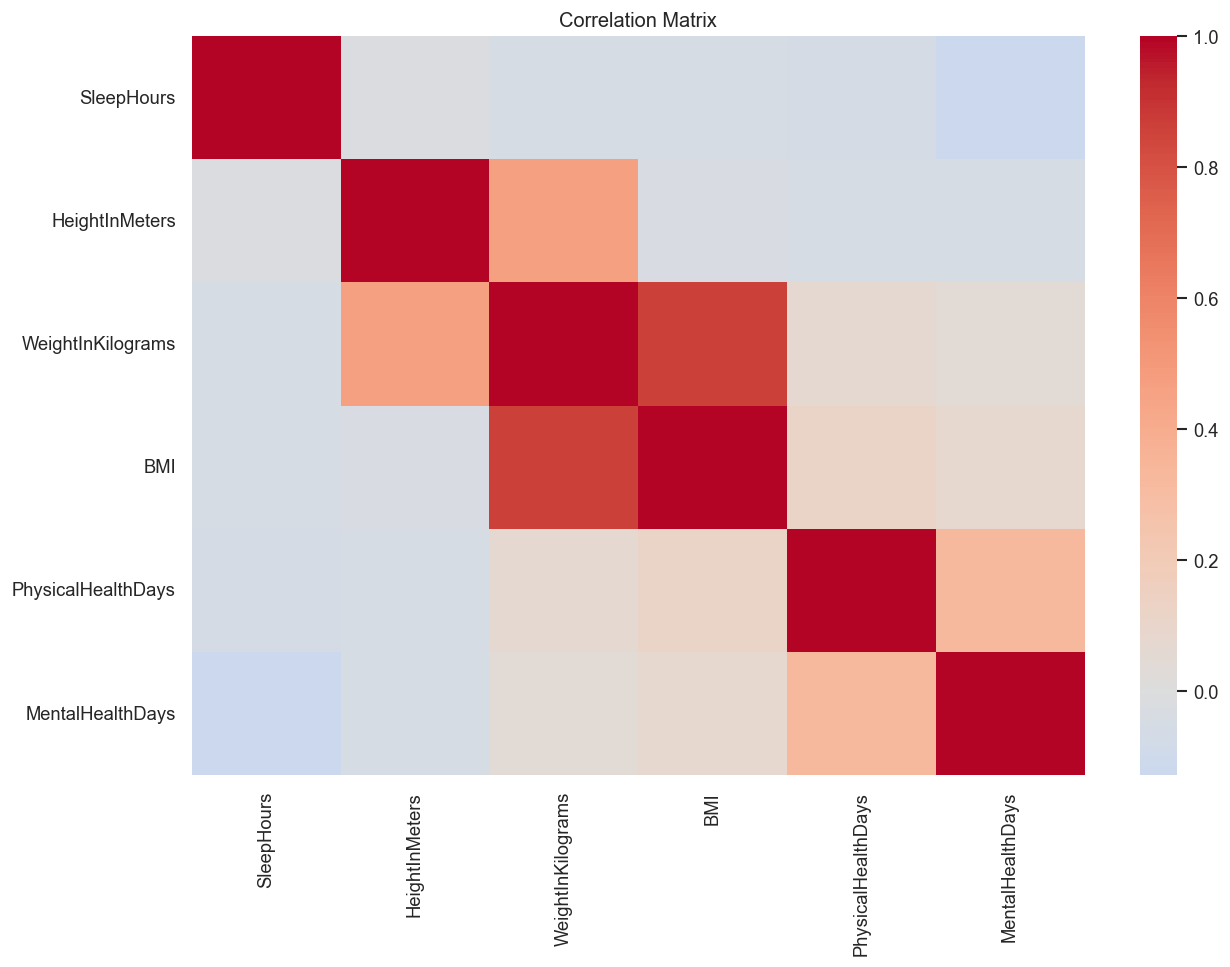

In [16]:
# Heatmap korelasi
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

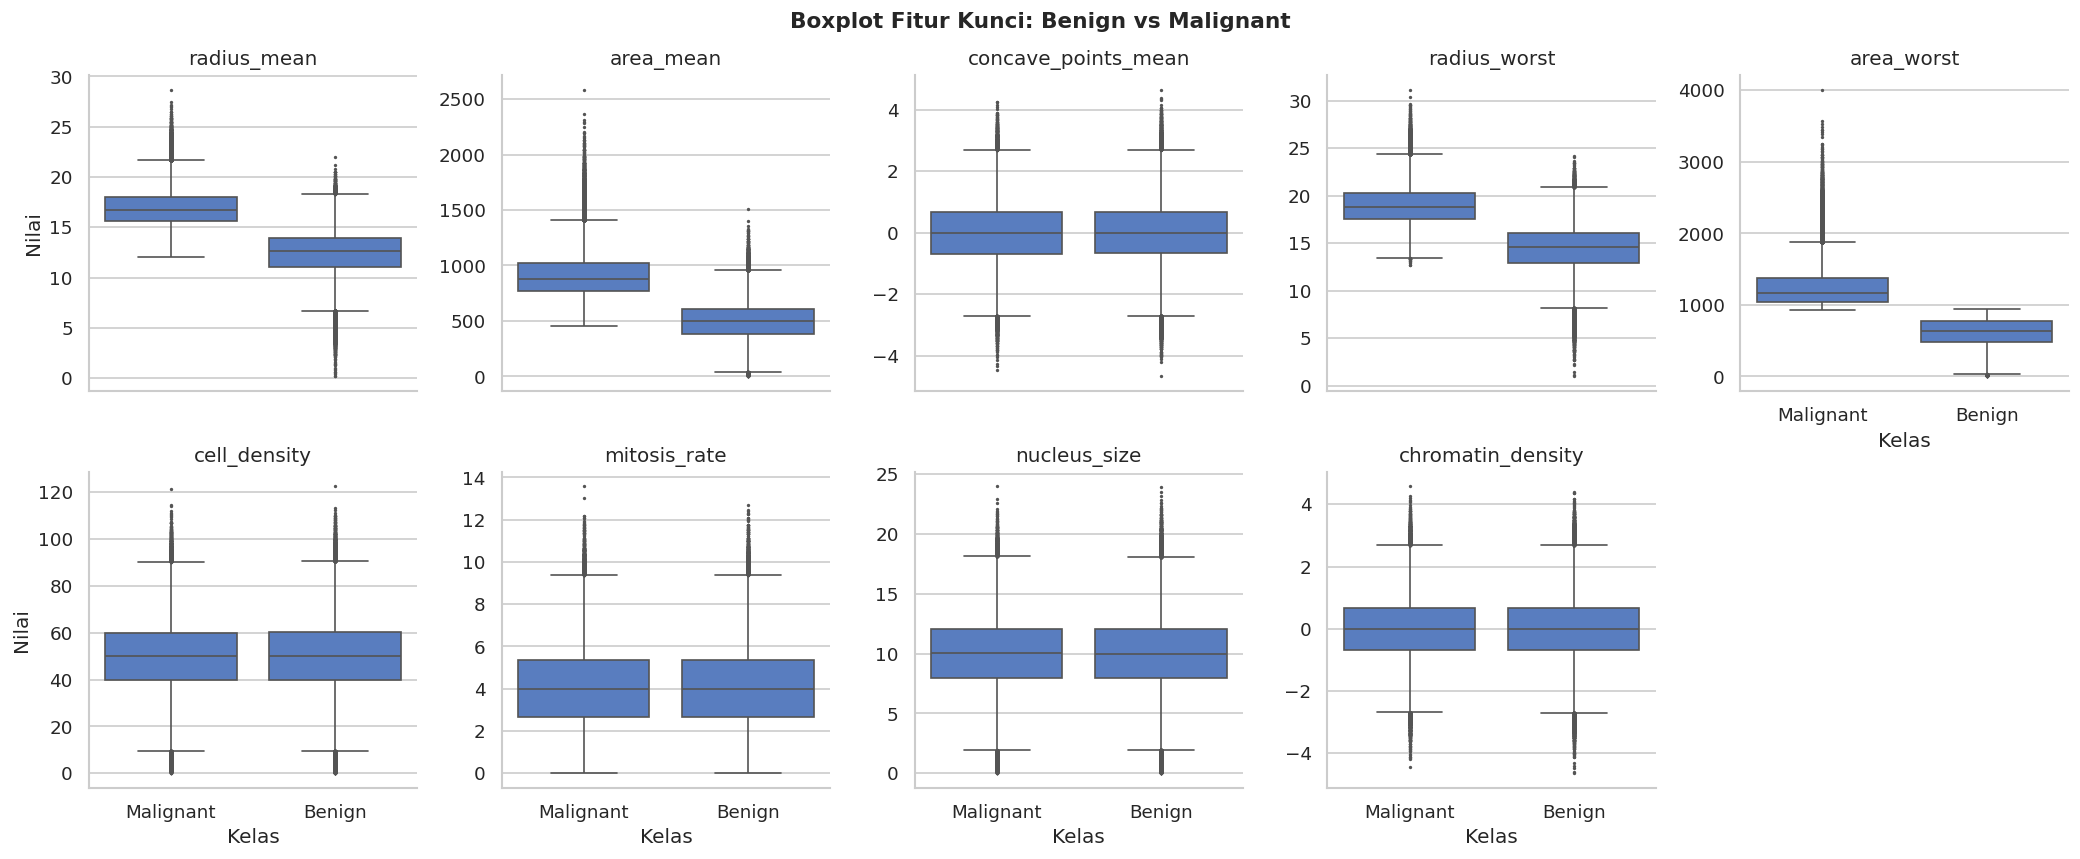

In [50]:
# Boxplot fitur-fitur kunci
key_features = ['radius_mean', 'area_mean', 'concave_points_mean',
                 'radius_worst', 'area_worst', 'cell_density',
                 'mitosis_rate', 'nucleus_size', 'chromatin_density']
key_features = [f for f in key_features if f in df.columns]

df_melt = df[key_features + [target_col]].melt(id_vars=target_col)
df_melt['label'] = df_melt[target_col].map({0: 'Benign', 1: 'Malignant'})

g = sns.FacetGrid(df_melt, col='variable', col_wrap=5, height=3.5, sharey=False)
g.map_dataframe(sns.boxplot, x='label', y='value', flierprops={'markersize': 1})
g.set_titles(col_template='{col_name}')
g.set_axis_labels('Kelas', 'Nilai')
g.figure.suptitle('Boxplot Fitur Kunci: Benign vs Malignant', fontsize=13, fontweight='bold', y=1.02)
plt.show()